#**Mounting Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#**Importing Libraries**

In [2]:
import os
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

pd.set_option("display.max_columns", None)

#**Loading Dataset**

In [3]:
datax = "/content/drive/MyDrive/bank-data"

if not os.path.exists(datax):
    raise FileNotFoundError(
        f"Could not find the folder: {datax}. "
        "Check the folder name/location in Google Drive."
    )

print("Files/folders in bank-data:")
for item in os.listdir(datax):
    print(" -", item)

csv_path = None
for root, dirs, files in os.walk(datax):
    if "bank-full.csv" in files:
        csv_path = os.path.join(root, "bank-full.csv")
        break

if csv_path is None:
    raise FileNotFoundError(
        "bank-full.csv was not found inside the bank-data folder. "
        "Check the filename and folder contents above."
    )

print("\nDataset file:", csv_path)

data = pd.read_csv(csv_path, sep=";")

print("\nDataset loaded successfully!")
print("Shape:", data.shape)
display(data.head())


Files/folders in bank-data:
 - __MACOSX
 - bank-data

Dataset file: /content/drive/MyDrive/bank-data/bank-data/bank-full.csv

Dataset loaded successfully!
Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


#**Dataset Overview**

In [4]:
print("Shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

print("\nData Types:")
display(data.dtypes.to_frame("Data Type"))

print("\nFirst 5 Rows:")
display(data.head())

Shape: (45211, 17)

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Data Types:


,Data Type
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64



First 5 Rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
display(data.describe())

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


#**Missing and Unknown Value Check**

In [6]:
print("Missing Values:")
display(data.isnull().sum().to_frame("Missing Count"))

print("Duplicate Rows:", data.duplicated().sum())

print("\nUnknown Values:")
unknown_counts = (data == "unknown").sum()
display(unknown_counts[unknown_counts > 0].to_frame("Unknown Count"))

Missing Values:


,Missing Count
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


Duplicate Rows: 0

Unknown Values:


,Unknown Count
job,288
education,1857
contact,13020
poutcome,36959


#**Target Distribution**

Target Distribution:


,Count
y,
no,39922
yes,5289


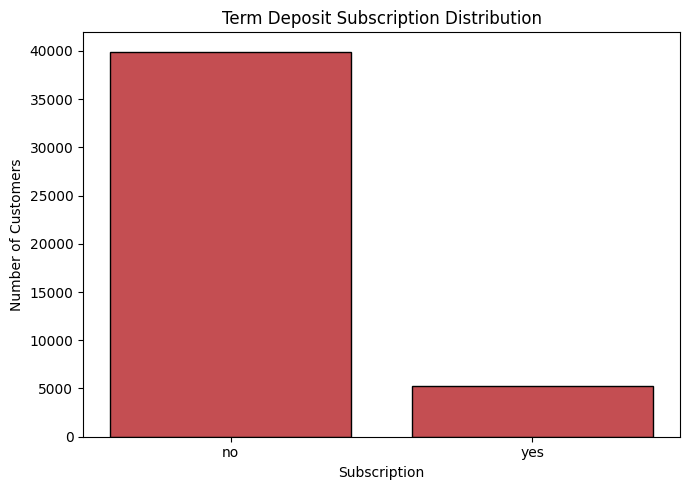

In [8]:
target_counts = data["y"].value_counts()

print("Target Distribution:")
display(target_counts.to_frame("Count"))

plt.figure(figsize=(7, 5))
plt.bar(
    target_counts.index, target_counts.values, color="#C44E52", edgecolor="black"
)

plt.title("Term Deposit Subscription Distribution")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

#**Identifying Feature Types**

In [ ]:
numerical_columns = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", numerical_columns)
print("\nCategorical columns:", categorical_columns)

Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


#**Distribution Plot For Selected Categorical Features**

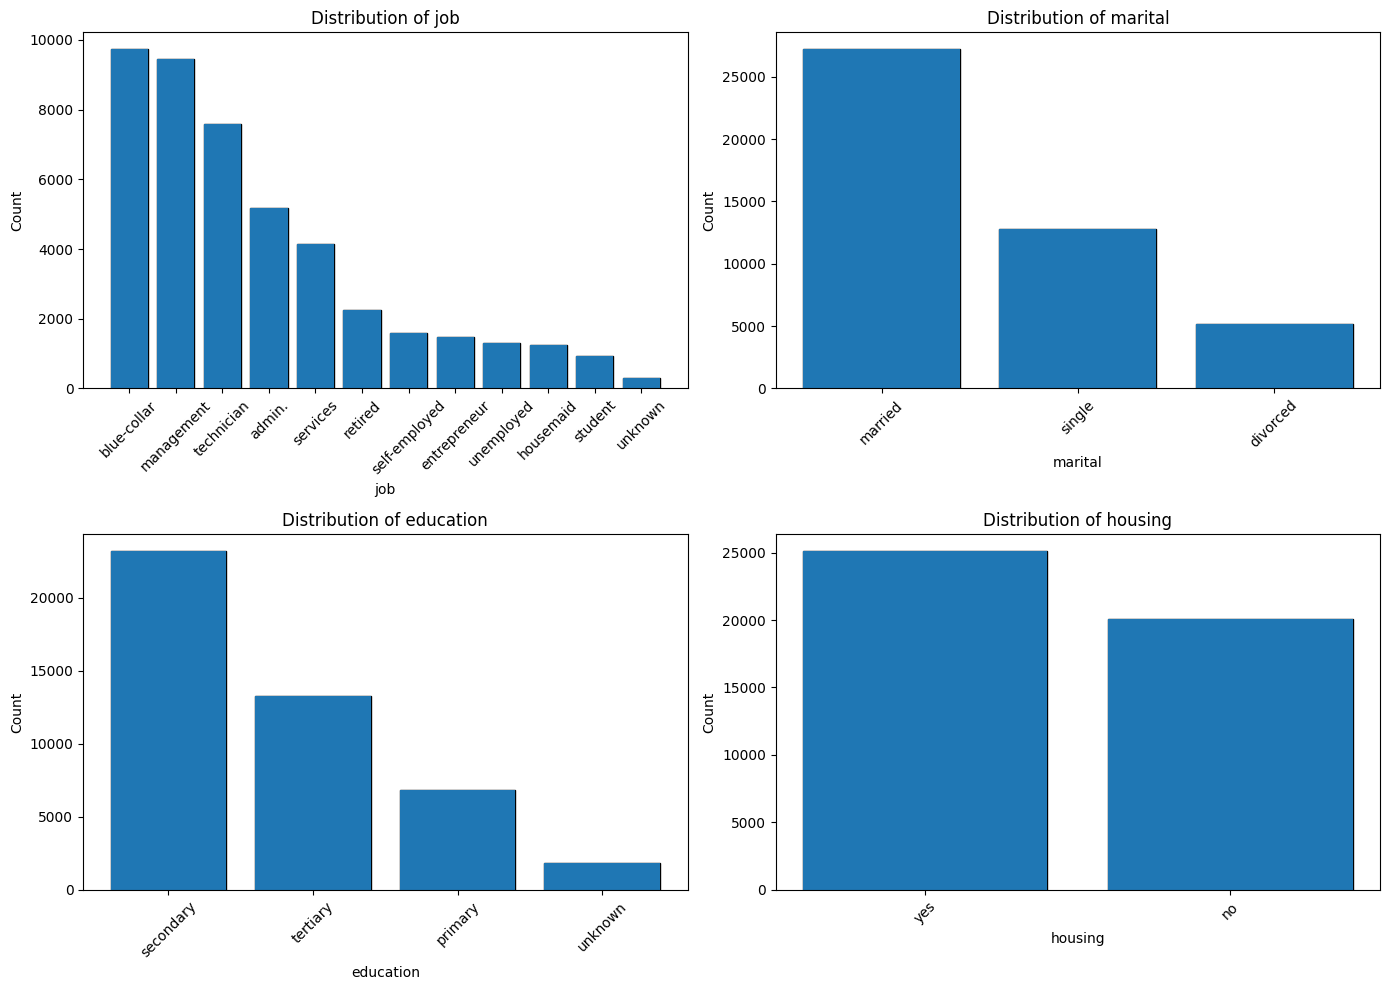

In [14]:
features = ["job", "marital", "education", "housing"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, col in zip(axes, features):
    counts = data[col].value_counts()
    ax.bar(
        counts.index, counts.values, color="#4C72B0", edgecolor="black"
    )
    ax.bar(counts.index, counts.values)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#**Subscription Rate For Selected Features**

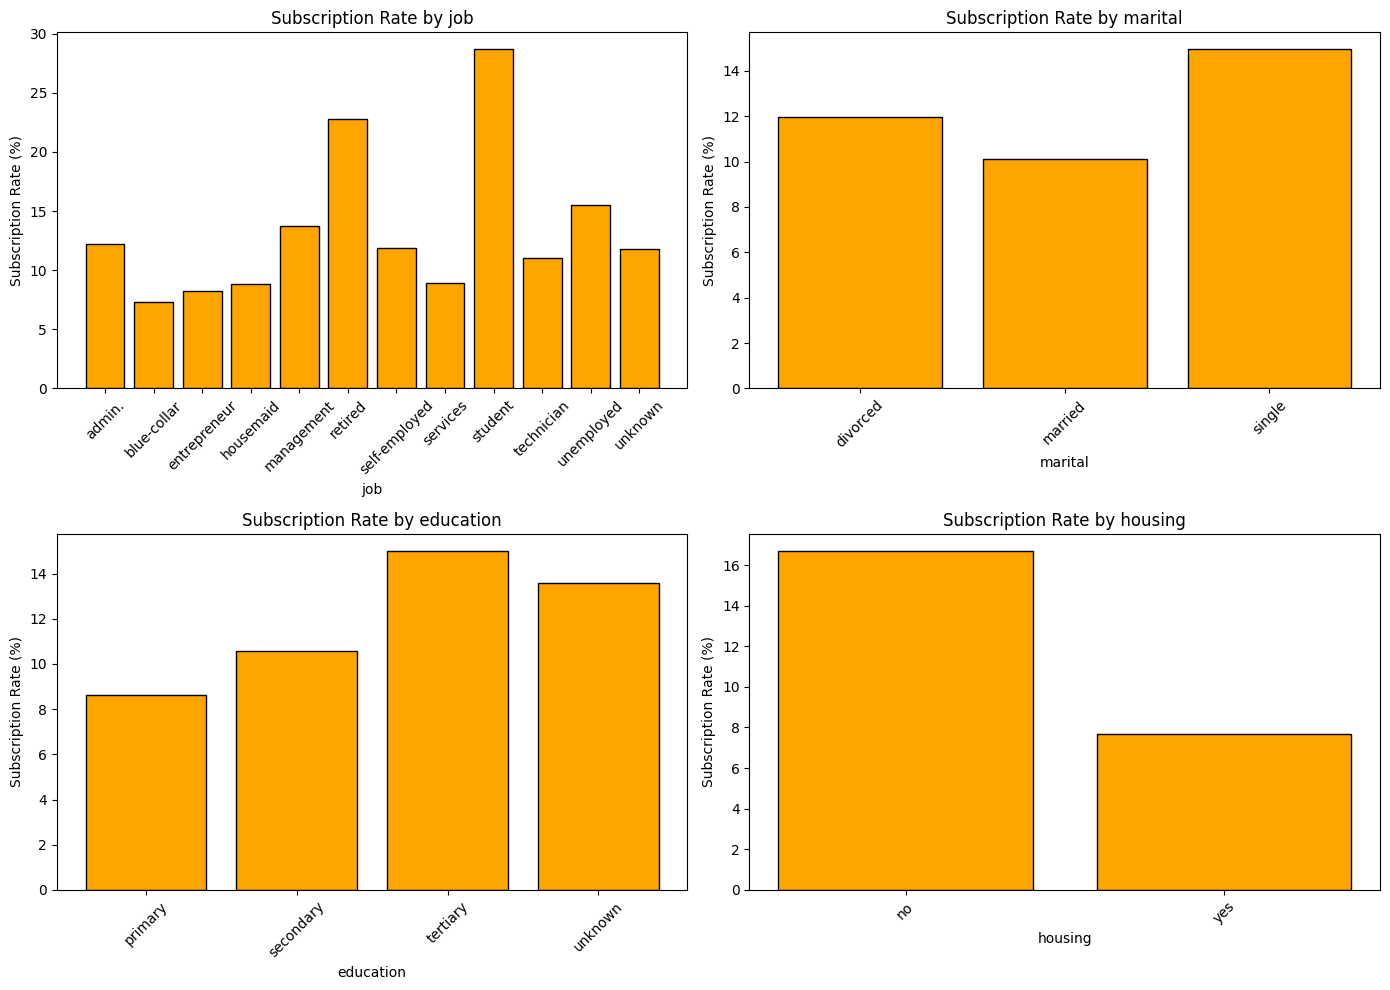

In [16]:
features = ["job", "marital", "education", "housing"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, col in zip(axes, features):
    rates = data.groupby(col)["y"].apply(lambda x: (x == "yes").mean() * 100)
    ax.bar(
        rates.index, rates.values, color="#FFA500", edgecolor="black"
    )
    ax.set_title(f"Subscription Rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Subscription Rate (%)")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#**Seperating Features & Target**

In [ ]:
X = data.drop("y", axis=1)
y = data["y"].map({"no": 0, "yes": 1})

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget counts:")
print(y.value_counts().sort_index())

Features shape: (45211, 16)
Target shape: (45211,)

Target counts:
y
0    39922
1     5289
Name: count, dtype: int64


#**Splitting Dataset into Train & Test Set**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (36168, 16)
Test set: (9043, 16)


#**Preprocessing**

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numerical_columns),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (36168, 51)
Processed testing shape: (9043, 51)


#**Logistic Regression Model Building & Training**

In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print(logistic_model)

logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression model trained successfully.")

LogisticRegression(max_iter=1000, random_state=42)
Logistic Regression model trained successfully.


#**Generating Predictions**

In [ ]:
y_pred = logistic_model.predict(X_test_processed)

y_probability = logistic_model.predict_proba(X_test_processed)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


#**Test Set Results**

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Test Set Results:")
print("-----------------------------------")
print(f"Accuracy    : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision   : {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall      : {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1 Score    : {f1:.4f} ({f1 * 100:.2f}%)")

Test Set Results:
-----------------------------------
Accuracy    : 0.9012 (90.12%)
Precision   : 0.6445 (64.45%)
Recall      : 0.3478 (34.78%)
F1 Score    : 0.4518 (45.18%)


#**Classification Report**

In [ ]:
print(classification_report(
    y_test, y_pred, target_names=["NO", "YES"], digits=4, zero_division=0
))

              precision    recall  f1-score   support

          NO     0.9186    0.9746    0.9457      7985
         YES     0.6445    0.3478    0.4518      1058

    accuracy                         0.9012      9043
   macro avg     0.7815    0.6612    0.6988      9043
weighted avg     0.8865    0.9012    0.8879      9043



#**Confusion Matrix**

Confusion Matrix:
[[7782  203]
 [ 690  368]]


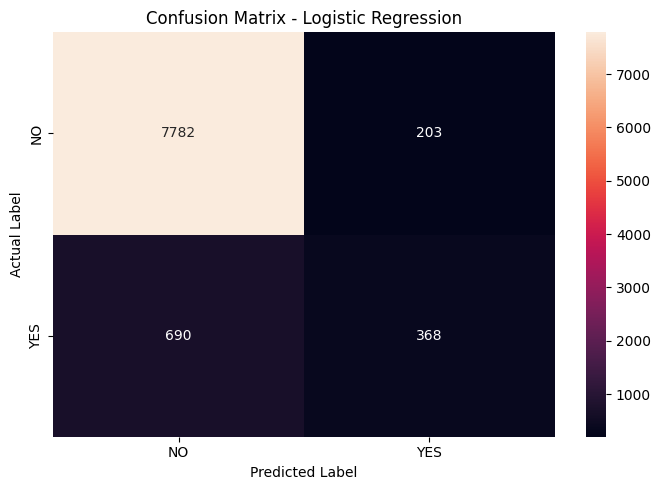

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=["NO", "YES"],
    yticklabels=["NO", "YES"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

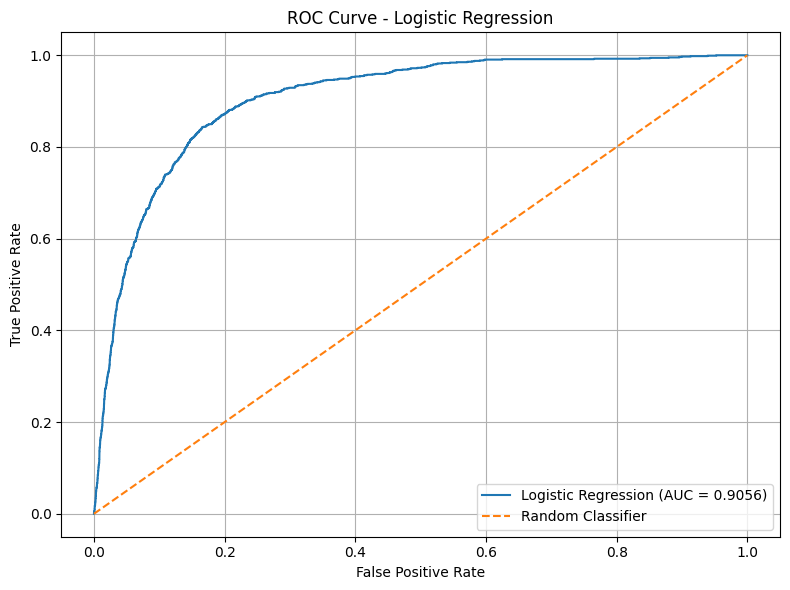

ROC-AUC Score: 0.9056


In [ ]:
fp_rate, tp_rate, thresholds = roc_curve(y_test, y_probability)
auc_score = roc_auc_score(y_test, y_probability)

plt.figure(figsize=(8, 6))
plt.plot(fp_rate, tp_rate, label=f"Logistic Regression (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

#**Metrics Summary Table**

In [ ]:
evaluation_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, auc_score],
    "Percentage": [
        f"{accuracy * 100:.2f}%",
        f"{precision * 100:.2f}%",
        f"{recall * 100:.2f}%",
        f"{f1 * 100:.2f}%",
        f"{auc_score * 100:.2f}%"
    ]
})

display(evaluation_metrics)

,Metric,Score,Percentage
0,Accuracy,0.901250,90.12%
1,Precision,0.644483,64.45%
2,Recall,0.347826,34.78%
3,F1 Score,0.451811,45.18%
4,ROC-AUC,0.905574,90.56%
